2025-04-01 12:58:27,496 - INFO - Loading spectral data...
2025-04-01 12:58:27,497 - INFO - Processing RGB data...
2025-04-01 12:58:27,498 - INFO - Normalizing RGB data...
2025-04-01 12:58:27,500 - INFO - Training the model...
2025-04-01 12:58:27,522 - INFO - Epoch 1/2000 - Training Loss: 0.0669 - Validation Loss: 0.0427
2025-04-01 12:58:27,542 - INFO - Epoch 2/2000 - Training Loss: 0.0217 - Validation Loss: 0.0157
2025-04-01 12:58:27,563 - INFO - Epoch 3/2000 - Training Loss: 0.0106 - Validation Loss: 0.0099
2025-04-01 12:58:27,583 - INFO - Epoch 4/2000 - Training Loss: 0.0070 - Validation Loss: 0.0066
2025-04-01 12:58:27,604 - INFO - Epoch 5/2000 - Training Loss: 0.0049 - Validation Loss: 0.0048
2025-04-01 12:58:27,624 - INFO - Epoch 6/2000 - Training Loss: 0.0037 - Validation Loss: 0.0036
2025-04-01 12:58:27,644 - INFO - Epoch 7/2000 - Training Loss: 0.0029 - Validation Loss: 0.0029
2025-04-01 12:58:27,665 - INFO - Epoch 8/2000 - Training Loss: 0.0025 - Validation Loss: 0.0025
2025-0

Mean ΔE2000 Error: 2.865269801195695
Max ΔE2000 Error: 5.290690586899741


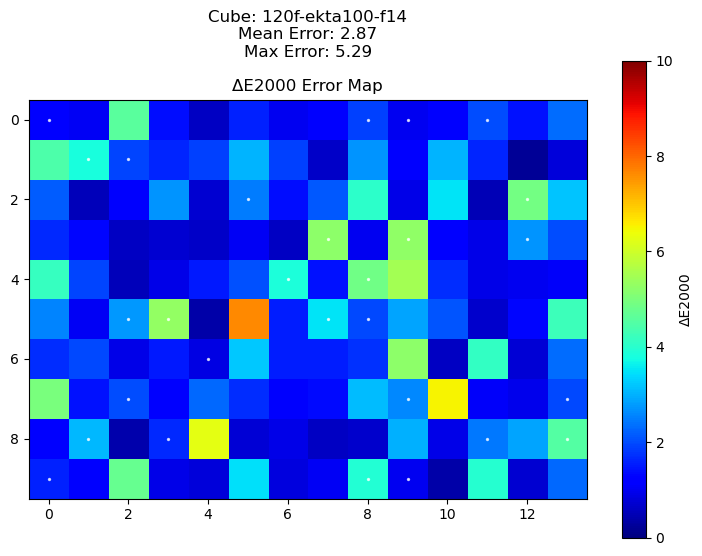

2025-04-01 12:59:08,301 - WARNING - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.26302022..1.0243117].


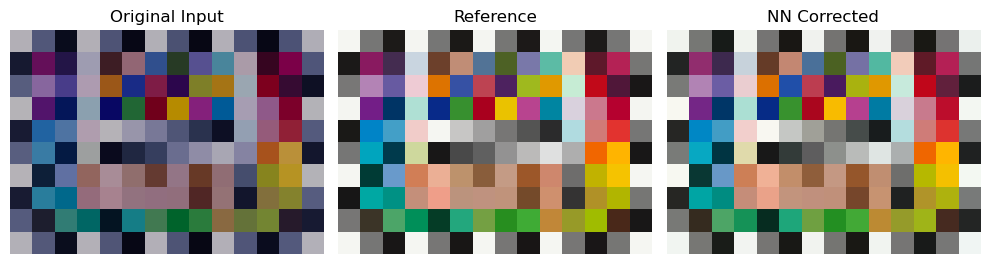

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import logging
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import spectral
import random
from skimage import color
import matplotlib.pyplot as plt
import copy
import os

###########################################
# Set up logging and seeds
###########################################
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

###########################################
# Helper functions for RGB->Lab conversion in torch
###########################################
def srgb_to_linear(x):
    # x is assumed to be in [0,1]
    threshold = 0.04045
    return torch.where(x <= threshold, x / 12.92, ((x + 0.055) / 1.055) ** 2.4)

def rgb_to_xyz_torch(rgb):
    """
    Convert sRGB (in [0,1]) to XYZ.
    Assumes rgb is a tensor of shape (N,3) with values in [0,1].
    """
    # First convert to linear RGB
    rgb_lin = srgb_to_linear(rgb)
    # sRGB to XYZ matrix (D65)
    M = torch.tensor([[0.4124564, 0.3575761, 0.1804375],
                      [0.2126729, 0.7151522, 0.0721750],
                      [0.0193339, 0.1191920, 0.9503041]], dtype=rgb.dtype, device=rgb.device)
    xyz = torch.matmul(rgb_lin, M.t())
    return xyz

def f_xyz(t):
    delta = 6/29
    delta3 = delta**3
    return torch.where(t > delta3, t ** (1/3), t / (3 * delta**2) + 4/29)

def xyz_to_lab_torch(xyz):
    # D65 white point
    Xn, Yn, Zn = 0.95047, 1.00000, 1.08883
    X = xyz[:, 0] / Xn
    Y = xyz[:, 1] / Yn
    Z = xyz[:, 2] / Zn
    fX = f_xyz(X)
    fY = f_xyz(Y)
    fZ = f_xyz(Z)
    L = 116 * fY - 16
    a = 500 * (fX - fY)
    b = 200 * (fY - fZ)
    lab = torch.stack([L, a, b], dim=1)
    return lab

def rgb_to_lab_torch(rgb):
    """
    Converts a tensor of RGB values (shape (N,3) in [0,1]) to Lab.
    """
    xyz = rgb_to_xyz_torch(rgb)
    lab = xyz_to_lab_torch(xyz)
    return lab

###########################################
# Your existing helper function for spectral processing
###########################################
def process_rgb(cube, bands, ill, CMFs):
    ill_interp = np.interp(bands, ill[:, 0], ill[:, 1])
    CMFs_interp = np.column_stack([
        np.interp(bands, CMFs[:, 0], CMFs[:, 1]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 2]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 3])
    ])
    sp_tristREF = CMFs_interp * ill_interp[:, None]
    xyz = np.dot(cube, sp_tristREF) / np.sum(sp_tristREF[:, 1], axis=0)
    rgb = color.xyz2rgb(xyz)
    return rgb

###########################################
# 1. Load spectral data
###########################################
logging.info('Loading spectral data...')
ill = np.loadtxt('../../data/CIE_D65.txt')          
CMFs = np.loadtxt('../../data/CIE2degCMFs_1931.txt')

cube_path = '../../data/colorChecker_SG/cubes/cubeCC_120f-ekta100-f14.hdr'
cube = spectral.open_image(cube_path)
cube_ref = spectral.open_image('../../data/colorChecker_SG/cubeCC_DigitalSG_REF.hdr')
cube_data = cube.load()         
cube_ref_data = cube_ref.load()
wl_input = np.array(cube.metadata['wavelength'], dtype=float)
wl_ref   = np.array(cube_ref.metadata['wavelength'], dtype=float)

###########################################
# 2. Process RGB data
###########################################
logging.info('Processing RGB data...')
rgb_input = process_rgb(cube_data, wl_input, ill, CMFs)   
rgb_ref   = process_rgb(cube_ref_data, wl_ref, ill, CMFs)   
H, W, C = rgb_input.shape

###########################################
# 3. Normalize data in RGB space using StandardScaler
###########################################
logging.info('Normalizing RGB data...')
rgb_input_2d = rgb_input.reshape(-1, C)
rgb_ref_2d   = rgb_ref.reshape(-1, C)

scaler_input = StandardScaler()
scaler_ref = StandardScaler()
X_norm = scaler_input.fit_transform(rgb_input_2d)
Y_norm = scaler_ref.fit_transform(rgb_ref_2d)

X_full = X_norm.reshape(rgb_input.shape)
Y_full = Y_norm.reshape(rgb_ref.shape)

###########################################
# 4. Prepare training data
###########################################
X_flat = X_full.reshape(-1, 3)
Y_flat = Y_full.reshape(-1, 3)
n_pixels = X_flat.shape[0]
train_size = int(0.8 * n_pixels)
train_indices = np.random.choice(n_pixels, train_size, replace=False)
test_indices = np.setdiff1d(np.arange(n_pixels), train_indices)
X_train_split = X_flat[train_indices]
X_test_split  = X_flat[test_indices]
Y_train_split = Y_flat[train_indices]
Y_test_split  = Y_flat[test_indices]
X_train_torch = torch.tensor(X_train_split, dtype=torch.float32)
Y_train_torch = torch.tensor(Y_train_split, dtype=torch.float32)
X_test_torch  = torch.tensor(X_test_split, dtype=torch.float32)
Y_test_torch  = torch.tensor(Y_test_split, dtype=torch.float32)

###########################################
# 5. Define a simple MLP model
###########################################
class SimpleMLP(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, output_size=3):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))
    
###########################################
# 6. Define the new hybrid loss: MSE (in RGB) and ΔE in Lab
###########################################
class HybridMSEDeltaELoss(nn.Module):
    def __init__(self, alpha=0.5, eps=1e-6, scaler_mean=None, scaler_scale=None):
        """
        alpha: weight for MSE (0 <= alpha <= 1). The delta E loss weight is (1 - alpha).
        scaler_mean, scaler_scale: numpy arrays (shape (3,)) from scaler_ref for un-standardizing.
        """
        super(HybridMSEDeltaELoss, self).__init__()
        self.alpha = alpha
        self.eps = eps
        self.mse_loss = nn.MSELoss()
        # Convert scaler parameters to torch tensors
        if scaler_mean is None or scaler_scale is None:
            raise ValueError("scaler_mean and scaler_scale must be provided")
        self.register_buffer('mean', torch.tensor(scaler_mean, dtype=torch.float32))
        self.register_buffer('scale', torch.tensor(scaler_scale, dtype=torch.float32))
    
    def forward(self, y_pred, y_true):
        # Un-standardize (linear transformation) so that:
        # original_rgb = standardized * scale + mean
        # Here both y_pred and y_true are of shape (N, 3)
        y_pred_orig = y_pred * self.scale + self.mean
        y_true_orig = y_true * self.scale + self.mean
        # Clamp values to [0,1] (if needed)
        y_pred_orig = torch.clamp(y_pred_orig, 0.0, 1.0)
        y_true_orig = torch.clamp(y_true_orig, 0.0, 1.0)
        
        # Compute MSE on original RGB values
        mse = self.mse_loss(y_pred_orig, y_true_orig)
        
        # Convert RGB to Lab (each of shape (N,3))
        lab_pred = rgb_to_lab_torch(y_pred_orig)
        lab_true = rgb_to_lab_torch(y_true_orig)
        # Compute delta E as Euclidean distance in Lab space
        delta_e = torch.norm(lab_pred - lab_true, p=2, dim=1)  # shape (N,)
        delta_e_loss = torch.mean(delta_e)
        
        # Total hybrid loss
        total_loss = self.alpha * mse + (1 - self.alpha) * delta_e_loss
        return total_loss

###########################################
# 7. Set up model, optimizer, scheduler, and early stopping
###########################################
model = SimpleMLP(input_size=3, hidden_size=128, output_size=3)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
# Create the hybrid loss using the scaler_ref parameters (mean and scale)
loss_function = HybridMSEDeltaELoss(alpha=1, scaler_mean=scaler_ref.mean_, scaler_scale=scaler_ref.scale_)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=300, gamma=0.5)
# Early stopping as defined previously
class EarlyStopping:
    def __init__(self, patience=10, delta=0, verbose=False, path='best_model.pth'):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.path = path
        self.best_loss = None
        self.counter = 0
        self.early_stop = False
        self.best_model_wts = None
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model_wts = copy.deepcopy(model.state_dict())
        elif val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.best_model_wts = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                # if self.verbose:
                    # print(f"Early stopping triggered after {self.counter} epochs with no improvement.")
        return self.early_stop

early_stopping = EarlyStopping(patience=50, delta=0, verbose=True)

###########################################
# 8. Training loop (using the hybrid loss)
###########################################
epochs = 2000
batch_size = 4
train_losses = []
val_losses = []

logging.info('Training the model...')
for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_train_torch.size(0))
    X_train_shuffled = X_train_torch[perm]
    Y_train_shuffled = Y_train_torch[perm]
    epoch_train_loss = 0.0
    for i in range(0, X_train_shuffled.size(0), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        Y_batch = Y_train_shuffled[i:i+batch_size]
        optimizer.zero_grad()
        Y_pred = model(X_batch)
        loss = loss_function(Y_pred, Y_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    avg_train_loss = epoch_train_loss / (X_train_shuffled.size(0) // batch_size)
    train_losses.append(avg_train_loss)
    scheduler.step()
    model.eval()
    with torch.no_grad():
        Y_val_pred = model(X_test_torch)
        val_loss = loss_function(Y_val_pred, Y_test_torch).item()
    val_losses.append(val_loss)
    logging.info(f'Epoch {epoch+1}/{epochs} - Training Loss: {avg_train_loss:.4f} - Validation Loss: {val_loss:.4f}')
    early_stop_flag = early_stopping(val_loss, model)
    # if early_stop_flag:
        # logging.info("Early stopping triggered.")
        # break

# Load the best model weights
model.load_state_dict(early_stopping.best_model_wts)

###########################################
# 9. Apply correction and evaluate with ΔE2000
###########################################
logging.info('Applying correction to the full target...')
X_full_flat = X_full.reshape(-1, 3)
corrected_flat = model(torch.tensor(X_full_flat, dtype=torch.float32)).detach().numpy()
corrected_rgb = scaler_ref.inverse_transform(corrected_flat)
corrected_rgb_image = corrected_rgb.reshape(rgb_ref.shape)

# Convert corrected and reference RGB to Lab (using skimage for evaluation)
corrected_lab = color.rgb2lab(corrected_rgb_image)
lab_ref = color.rgb2lab(rgb_ref)
error_map = color.deltaE_ciede2000(lab_ref, corrected_lab)
error_map_flat = error_map.reshape(-1)
test_error_values = error_map_flat[test_indices]
mean_error_test = np.mean(test_error_values)
max_error_test = np.max(test_error_values)
print("Mean ΔE2000 Error:", mean_error_test)
print("Max ΔE2000 Error:", max_error_test)

# Plot error map and images
plt.figure(figsize=(8, 6))
plt.imshow(error_map, cmap='jet', vmin=0, vmax=10)
plt.colorbar(label='ΔE2000')
test_positions = np.unravel_index(test_indices, lab_ref.shape[:2])
plt.scatter(test_positions[1], test_positions[0], s=2, c='white', label='Test Patches', alpha=0.7)
plt.title('ΔE2000 Error Map')
file_name = os.path.splitext(os.path.basename(cube_path))[0]
file_name = file_name.split('_', 1)[-1]
plt.text(0.5, 1.1, f'Cube: {file_name}\nMean Error: {mean_error_test:.2f}\nMax Error: {max_error_test:.2f}', 
         ha='center', va='bottom', transform=plt.gca().transAxes, fontsize=12, color='black')
plt.tight_layout(pad=3.0)
plt.show()

plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(rgb_input)
plt.title('Original Input')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(rgb_ref)
plt.title('Reference')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(corrected_rgb_image)
plt.title('NN Corrected')
plt.axis('off')
plt.tight_layout()
plt.show()
